# Set Up Notebook

In [1]:
##########
# IMPORT #
##########

# Data processing and math
import pandas as pd
import numpy as np

# Statistics
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display handling
import warnings


#################
# CONFIGURATION #
#################

# Suppress warnings
warnings.filterwarnings('ignore')

# Set global plotting style
sns.set_theme(style = "whitegrid")


##########
# LABELS #
##########
labels_measure = {
    'measure_action': 'Responsibility for Action',
    'measure_blame':  'Blame / Praise'
}


#################
# VISUALIZATION #
#################
palette_main = {
    "Good":      "#0072B2", "Bad":         "#D55E00",
    "Activist":  "#56B4E9", "Bigot":       "#E69F00",
    "Help":      "#F0E442", "Harm":        "#882255"
}

# Transform Data

In [2]:
# Load data
df = pd.read_csv('blame_praise_self_pilot_2.csv')

# Define factors
def get_factors(n):
    idx = int(n) - 1
    upbringing = "Good" if (idx >> 3) & 1 else "Bad"
    belief = "Bigot" if (idx >> 1) & 1 else "Activist"
    valence = "Harm" if idx & 1 else "Help"
    return upbringing, belief, valence

# Reshape wide to long
indices = [5, 6, 7, 8, 13, 14, 15, 16]
long_data = []

for _, row in df.iterrows():
    p_id = row['ID']
    
    for i in indices:
        col_action = f'homophobia.{i}-pAction'
        
        col_blame = None
        for col in df.columns:
            clean_col = col.replace('.', '')
            if clean_col.startswith(f'blame{i}'):
                col_blame = col
                break
        
        if col_action in df.columns and pd.notna(row[col_action]):
            up, bel, val = get_factors(i)
            
            score_action = pd.to_numeric(row[col_action], errors = 'coerce') - 7
            
            score_blame = np.nan
            if col_blame and pd.notna(row[col_blame]):
                score_blame = pd.to_numeric(row[col_blame], errors = 'coerce') - 7
            
            long_data.append({
                'ID': p_id,
                'Upbringing': up,
                'Belief': bel,
                'Action': val,
                'measure_action': score_action,
                'measure_blame': score_blame
            })

df_long = pd.DataFrame(long_data)
print(f"Transformation complete ({len(df_long)} Observations).")

Transformation complete (481 Observations).


# Calculate Descriptive Statistics

In [3]:
# Define group factors and dependent variables
group_factors = ['Upbringing', 'Belief', 'Action']
dependent_vars = ['measure_action', 'measure_blame']

# Calculate descriptive statistics
descriptive_stats = df_long.groupby(group_factors)[dependent_vars].agg(['mean', 'std', 'count']).round(3)

# Display results
display(descriptive_stats)

measure_action              measure_blame         \
                                     mean    std count          mean    std   
Upbringing Belief   Action                                                    
Bad        Activist Harm           -5.085  1.643    59        -5.186  2.013   
                    Help            4.852  1.537    61         4.164  1.781   
           Bigot    Harm           -4.483  2.514    60        -4.500  2.843   
                    Help            4.180  2.037    61         3.361  2.074   
Good       Activist Harm           -4.610  3.012    59        -4.661  3.004   
                    Help            4.900  1.591    60         3.733  2.449   
           Bigot    Harm           -5.262  1.413    61        -5.492  1.324   
                    Help            4.417  1.816    60         3.483  2.303   

                                  
                           count  
Upbringing Belief   Action        
Bad        Activist Harm      59  
                    Help      61  
           Bigot    Harm      60  
                    Help      61  
Good       Activist Harm      59  
                    Help      60  
           Bigot    Harm      61  
                    Help      60

# Perform ANOVAs

In [4]:
for dv in ['measure_action', 'measure_blame']:
    print(f"\nANOVA ({labels_measure.get(dv, dv)})")
    
    # Define formula and drop lines with NaN
    formula = f"{dv} ~ C(Upbringing) * C(Belief) * C(Action)"
    df_anova = df_long.dropna(subset=[dv])    
    model = ols(formula, data = df_anova).fit()
    
    # Run ANOVA
    aov_table = sm.stats.anova_lm(model, typ = 2)
    
    # Calculate effect sizes
    aov_table['partial_eta_sq'] = aov_table['sum_sq'] / (aov_table['sum_sq'] + aov_table.loc['Residual', 'sum_sq'])
    
    # Display results
    display(aov_table.round(3))


ANOVA (Responsibility for Action)


,sum_sq,df,F,PR(>F),partial_eta_sq
C(Upbringing),0.008,1.0,0.002,0.965,0.000
C(Belief),11.182,1.0,2.769,0.097,0.006
C(Action),10728.680,1.0,2656.797,0.000,0.849
C(Upbringing):C(Belief),8.374,1.0,2.074,0.151,0.004
C(Upbringing):C(Action),2.681,1.0,0.664,0.416,0.001
C(Belief):C(Action),9.220,1.0,2.283,0.131,0.005
C(Upbringing):C(Belief):C(Action),15.632,1.0,3.871,0.050,0.008
Residual,1910.069,473.0,NaN,NaN,0.500



ANOVA (Blame / Praise)


,sum_sq,df,F,PR(>F),partial_eta_sq
C(Upbringing),4.716,1.0,0.908,0.341,0.002
C(Belief),11.078,1.0,2.134,0.145,0.004
C(Action),8985.231,1.0,1730.773,0.000,0.785
C(Upbringing):C(Belief),6.795,1.0,1.309,0.253,0.003
C(Upbringing):C(Action),0.221,1.0,0.043,0.837,0.000
C(Belief):C(Action),6.266,1.0,1.207,0.272,0.003
C(Upbringing):C(Belief):C(Action),32.214,1.0,6.205,0.013,0.013
Residual,2455.558,473.0,NaN,NaN,0.500


# Generate Bar Plots

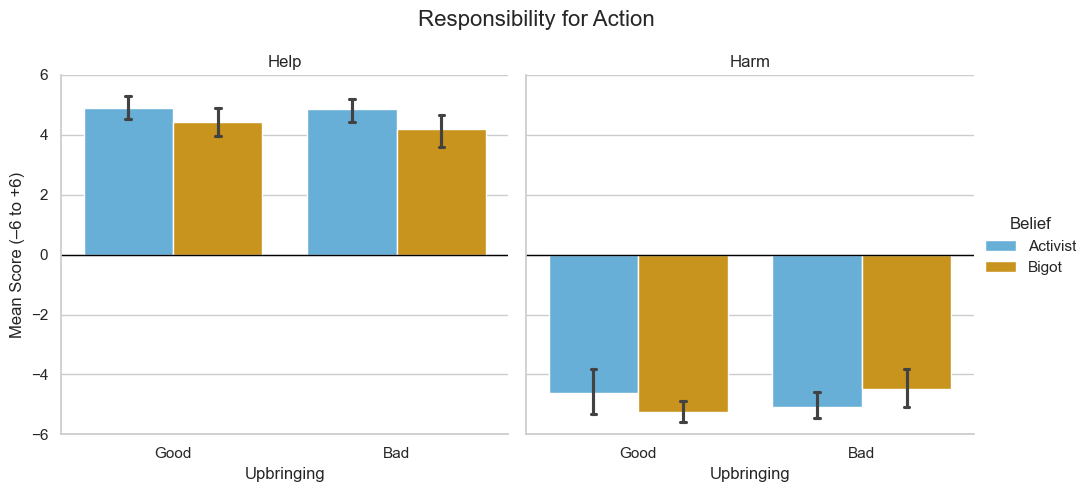

Graph saved as 'blame_praise_self_pilot_2_bar_plot_measure_action.png'.


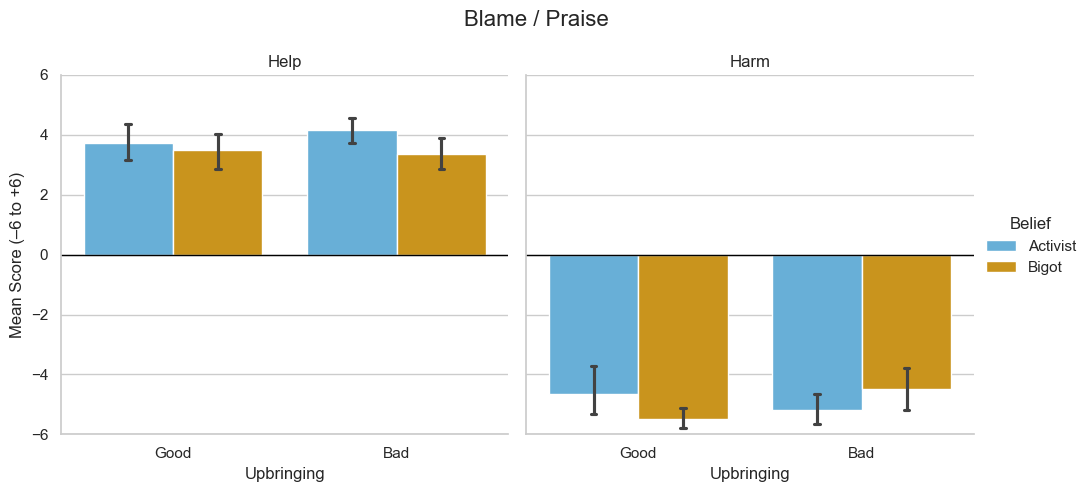

Graph saved as 'blame_praise_self_pilot_2_bar_plot_measure_blame.png'.


In [5]:
for measure in ['measure_action', 'measure_blame']:
    current_label = labels_measure.get(measure, measure)
    
    # Create graphs
    g = sns.catplot(data = df_long, x = "Upbringing", y = measure,
                    hue = "Belief", col = "Action", kind = "bar",
                    palette = palette_main, capsize = .05, height = 5)
    
    # Set axis labels and titles
    g.set_axis_labels("Upbringing", f"Mean Score (–6 to +6)")
    g.set_titles("{col_name}")
    
    # Add horizontal zero lines
    for ax in g.axes.flat:
        ax.axhline(0, color = 'black', lw = 1)
        ax.set_ylim(-6, 6)
    
    # Add main title
    plt.subplots_adjust(top = 0.85)
    g.fig.suptitle(current_label, fontsize = 16)
    
    # Export graphs
    filename = f'blame_praise_self_pilot_2_bar_plot_{measure}.png'
    g.savefig(filename, dpi = 300, bbox_inches = 'tight')
    plt.show()
    print(f"Graph saved as '{filename}'.")